In [5]:
import os
import torch
import timm
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, TensorDataset

In [6]:
DATASET_DIR = "dataset"
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
NUM_CLASSES = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [8]:
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
backbone = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True)
backbone.reset_classifier(0)  # remove classification head
backbone.to(DEVICE)
backbone.eval()

def extract_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            out = backbone(imgs)
            feats.append(out.cpu())
            labels.append(lbls)
    return torch.cat(feats), torch.cat(labels)

X_train_feats, y_train = extract_features(train_loader)
X_test_feats, y_test = extract_features(test_loader)

In [11]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=8, alpha=16):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.scale = alpha / r

        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        # LoRA params
        self.lora_A = nn.Parameter(torch.randn(r, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.randn(out_features, r) * 0.01)

    def forward(self, x):
        return torch.nn.functional.linear(
            x,
            self.weight + (self.lora_B @ self.lora_A) * self.scale,
            self.bias
        )

In [12]:
model_head = LoRALinear(X_train_feats.shape[1], NUM_CLASSES, r=8, alpha=16).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-4)

In [14]:
train_data = TensorDataset(X_train_feats, y_train)
train_loader_feats = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

EPOCHS = 20
for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0
    for xb, yb in train_loader_feats:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model_head(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader_feats):.4f}")

Epoch [1/20], Loss: 2.9428
Epoch [2/20], Loss: 2.6617
Epoch [3/20], Loss: 2.4267
Epoch [4/20], Loss: 2.2258
Epoch [5/20], Loss: 2.0522
Epoch [6/20], Loss: 1.9001
Epoch [7/20], Loss: 1.7684
Epoch [8/20], Loss: 1.6520
Epoch [9/20], Loss: 1.5485
Epoch [10/20], Loss: 1.4556
Epoch [11/20], Loss: 1.3698
Epoch [12/20], Loss: 1.2917
Epoch [13/20], Loss: 1.2198
Epoch [14/20], Loss: 1.1541
Epoch [15/20], Loss: 1.0940
Epoch [16/20], Loss: 1.0371
Epoch [17/20], Loss: 0.9849
Epoch [18/20], Loss: 0.9366
Epoch [19/20], Loss: 0.8913
Epoch [20/20], Loss: 0.8468


In [15]:
model_head.eval()
with torch.no_grad():
    y_pred = model_head(X_test_feats.to(DEVICE)).argmax(dim=1).cpu()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\n===== RESULTS =====")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")


===== RESULTS =====
Accuracy:  0.8287
Precision: 0.8317
Recall:    0.8302
F1 Score:  0.8301


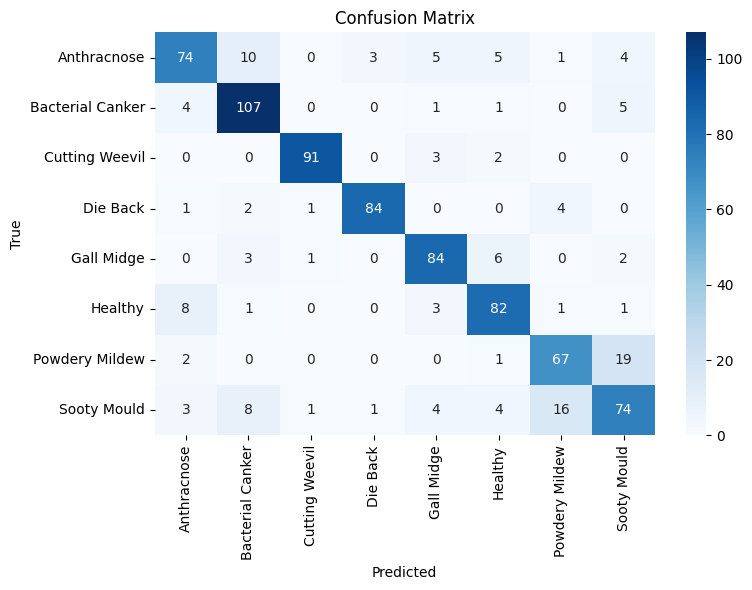

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CLASS_NAMES should match the order of your labels
CLASS_NAMES = [
    'Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 
    'Die Back', 'Gall Midge', 'Healthy', 
    'Powdery Mildew', 'Sooty Mould'
]

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
